In [164]:
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

True

In [165]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [166]:
# defining the max tokens
MAX_TOKENS = 33

In [167]:
def chat_node_trimmer(state: MessagesState):

    #triming before calling the messages

    messages = trim_messages(
        state['messages'],
        strategy='last', 
        token_counter=count_tokens_approximately, 
        max_tokens=MAX_TOKENS)
    
    print("Number of tokens in the messages:", count_tokens_approximately(messages=messages))
    
    response = LLM.invoke(messages)
    return {'messages': [response]}

In [168]:
# building the graph
graph = StateGraph(MessagesState)

graph.add_node("chat_node", chat_node_trimmer)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

memory = InMemorySaver()
Triming_STM = graph.compile(checkpointer=memory)

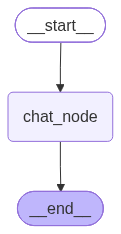

In [169]:
from IPython.display import Image
Image(Triming_STM.get_graph().draw_mermaid_png())

In [170]:
#creating the thread id for the chat
config1 = {"configurable": {"thread_id": "chat-2"}}

In [171]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hi"}]}, config=config1)

Number of tokens in the messages: 5


In [172]:
result['messages'][-1].content

'Hello! How can I help you today?'

In [173]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "i am learning about langgraph"}]}, config=config1)

Number of tokens in the messages: 31


In [174]:
result['messages'][-1].content

'That’s great! LangGraph is a powerful framework for building composable, state‑driven workflows with LLMs. Here’s a quick rundown to get you started, followed by some resources and example snippets you can try out.\n\n---\n\n## 1️⃣ What Is LangGraph?\n\n- **Purpose** – It lets you define **graph‑structured** (i.e., node‑and‑edge) workflows where each node is a piece of logic (often an LLM call, a tool, or custom Python code) and edges dictate how the conversation or data flows.\n- **State‑centric** – Every execution carries a mutable `state` dictionary that is passed between nodes. This makes it easy to keep track of context, variables, and intermediate results.\n- **Composable** – Nodes can be reused across different graphs, and you can nest sub‑graphs (think of them as “functions”) for modular design.\n- **Built on LangChain** – If you already know LangChain, you’ll feel right at home; LangGraph just adds the graph orchestration layer.\n\n---\n\n## 2️⃣ Core Concepts\n\n| Concept | D

In [175]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "can you write a 10 line paragraph on langgraph?"}]},config=config1)

Number of tokens in the messages: 16


In [176]:
result["messages"][-1].content

'LangGraph is an open‑source Python library that lets developers construct complex LLM‑driven workflows as directed graphs, where each node represents a distinct processing step.  \nIt builds on LangChain’s modular components, adding a clear, visualizable structure that makes debugging and iteration far more intuitive.  \nNodes can be simple prompts, function calls, or even custom agents, and edges define the flow of data and control between them.  \nThe library supports conditional branching, loops, and parallel execution, enabling sophisticated decision‑making and multi‑turn conversations.  \nState management is baked in, allowing each node to read from and write to a shared context without manual bookkeeping.  \nLangGraph integrates seamlessly with popular LLM providers (OpenAI, Anthropic, Cohere) and can be extended to any model that follows the standard chat/completion API.  \nIts declarative syntax lets you define graphs in plain Python or JSON, making it easy to version‑control 

In [177]:
result = Triming_STM.invoke({"messages": [{"role": "user", "content": "hello how are you what are you doing can you name good leetcode algorithms for my interview tomorrow?"}]}, config1)

Number of tokens in the messages: 30


In [178]:
result["messages"][-1].content

'Hey there! I’m doing great, thanks for asking. I’m here and ready to help you crush that interview tomorrow. 🎉\n\nBelow is a compact cheat‑sheet of the most frequently asked algorithmic topics on LeetCode (and similar platforms), along with a few representative problems you can solve to solidify each concept. Feel free to pick the ones that match the role you’re targeting (e.g., software engineering, data‑science, system‑design) and the time you have left to study.\n\n---\n\n## 1️⃣ Arrays & Strings\n| Concept | Why it matters | Classic LeetCode problems |\n|---------|----------------|---------------------------|\n| Two‑pointer technique | Linear‑time scanning, in‑place modifications | **Two Sum II – Sorted Array** (167), **Container With Most Water** (11), **Trapping Rain Water** (42) |\n| Sliding window | Optimal for sub‑array / substring constraints | **Longest Substring Without Repeating Characters** (3), **Maximum Sum Subarray of Size K** (209), **Minimum Window Substring** (76) |